In [1]:
!pip3 install numpy pandas matplotlib scipy


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

print("Librerie caricate correttamente!")

Librerie caricate correttamente!


In [3]:
# Asset del portafoglio
assets = {
    'S&P 500': {'mu': 0.10, 'sigma': 0.16, 'color': '#3266ad'},
    'Tech ETF': {'mu': 0.13, 'sigma': 0.22, 'color': '#7F77DD'},
    'Bonds':    {'mu': 0.03, 'sigma': 0.06, 'color': '#1D9E75'},
    'Gold':     {'mu': 0.06, 'sigma': 0.15, 'color': '#BA7517'},
    'Bitcoin':  {'mu': 0.40, 'sigma': 0.70, 'color': '#E24B4A'},
}

# Matrice di correlazione
corr_matrix = np.array([
    [1.00,  0.85, -0.10,  0.05,  0.15],
    [0.85,  1.00, -0.15,  0.02,  0.20],
    [-0.10,-0.15,  1.00,  0.30, -0.05],
    [0.05,  0.02,  0.30,  1.00,  0.10],
    [0.15,  0.20, -0.05,  0.10,  1.00],
])

# Pesi del portafoglio (devono sommare a 1)
weights = np.array([0.35, 0.25, 0.20, 0.10, 0.10])

# Parametri simulazione
CAPITAL    = 100_000   # capitale iniziale in €
N_SIM      = 500       # numero di simulazioni
T_DAYS     = 252       # orizzonte temporale (1 anno)
RISK_FREE  = 0.02      # tasso risk-free

names  = list(assets.keys())
mus    = np.array([a['mu']    for a in assets.values()])
sigmas = np.array([a['sigma'] for a in assets.values()])
colors = [a['color'] for a in assets.values()]

print("Portafoglio configurato!")
print(f"\nAsset e pesi:")
for name, w in zip(names, weights):
    print(f"  {name:<12} {w*100:.0f}%")

Portafoglio configurato!

Asset e pesi:
  S&P 500      35%
  Tech ETF     25%
  Bonds        20%
  Gold         10%
  Bitcoin      10%


In [4]:
def portfolio_stats(w, mus, sigmas, corr, rf=RISK_FREE):
    """Calcola rendimento, volatilità e Sharpe di un portafoglio."""
    port_mu = np.dot(w, mus)
    cov_matrix = np.outer(sigmas, sigmas) * corr
    port_variance = w @ cov_matrix @ w
    port_sigma = np.sqrt(port_variance)
    sharpe = (port_mu - rf) / port_sigma
    return port_mu, port_sigma, sharpe

mu_p, sigma_p, sharpe_p = portfolio_stats(weights, mus, sigmas, corr_matrix)

print("=" * 40)
print("   METRICHE DEL PORTAFOGLIO")
print("=" * 40)
print(f"  Rendimento annuo atteso : {mu_p*100:.2f}%")
print(f"  Volatilità annua        : {sigma_p*100:.2f}%")
print(f"  Sharpe Ratio            : {sharpe_p:.3f}")
print(f"  VaR 95% (1 anno)        : -{(norm.ppf(0.05, mu_p, sigma_p))*CAPITAL*-1:,.0f} €")
print(f"  VaR 99% (1 anno)        : -{(norm.ppf(0.01, mu_p, sigma_p))*CAPITAL*-1:,.0f} €")
print("=" * 40)

   METRICHE DEL PORTAFOGLIO
  Rendimento annuo atteso : 11.95%
  Volatilità annua        : 13.93%
  Sharpe Ratio            : 0.714
  VaR 95% (1 anno)        : -10,961 €
  VaR 99% (1 anno)        : -20,453 €


In [5]:
def run_monte_carlo(weights, mus, sigmas, corr, capital, n_sim, t_days):
    """
    Simula N percorsi del portafoglio usando GBM con correlazioni.
    Usa la decomposizione di Cholesky per generare rendimenti correlati.
    """
    dt = 1 / 252
    L  = np.linalg.cholesky(corr)   # decomposizione di Cholesky

    paths = np.zeros((n_sim, t_days + 1))
    paths[:, 0] = capital

    for t in range(1, t_days + 1):
        Z        = np.random.standard_normal((len(weights), n_sim))
        Z_corr   = L @ Z                                         # rend. correlati
        asset_ret = (mus - 0.5 * sigmas**2) * dt + sigmas * np.sqrt(dt) * Z_corr.T
        port_ret  = asset_ret @ weights                          # rendimento portafoglio
        paths[:, t] = paths[:, t-1] * np.exp(port_ret)

    return paths

np.random.seed(42)
paths = run_monte_carlo(weights, mus, sigmas, corr_matrix, CAPITAL, N_SIM, T_DAYS)

finals = paths[:, -1]
print(f"Simulazione completata: {N_SIM} percorsi x {T_DAYS} giorni")
print(f"\nValore finale — statistiche:")
print(f"  Mediana   : €{np.median(finals):>12,.0f}")
print(f"  Media     : €{np.mean(finals):>12,.0f}")
print(f"  5° pct    : €{np.percentile(finals, 5):>12,.0f}")
print(f"  95° pct   : €{np.percentile(finals, 95):>12,.0f}")
print(f"  P(profitto): {(finals > CAPITAL).mean()*100:.1f}%")

Simulazione completata: 500 percorsi x 252 giorni

Valore finale — statistiche:
  Mediana   : €     106,927
  Media     : €     108,662
  5° pct    : €      85,018
  95° pct   : €     136,528
  P(profitto): 68.6%


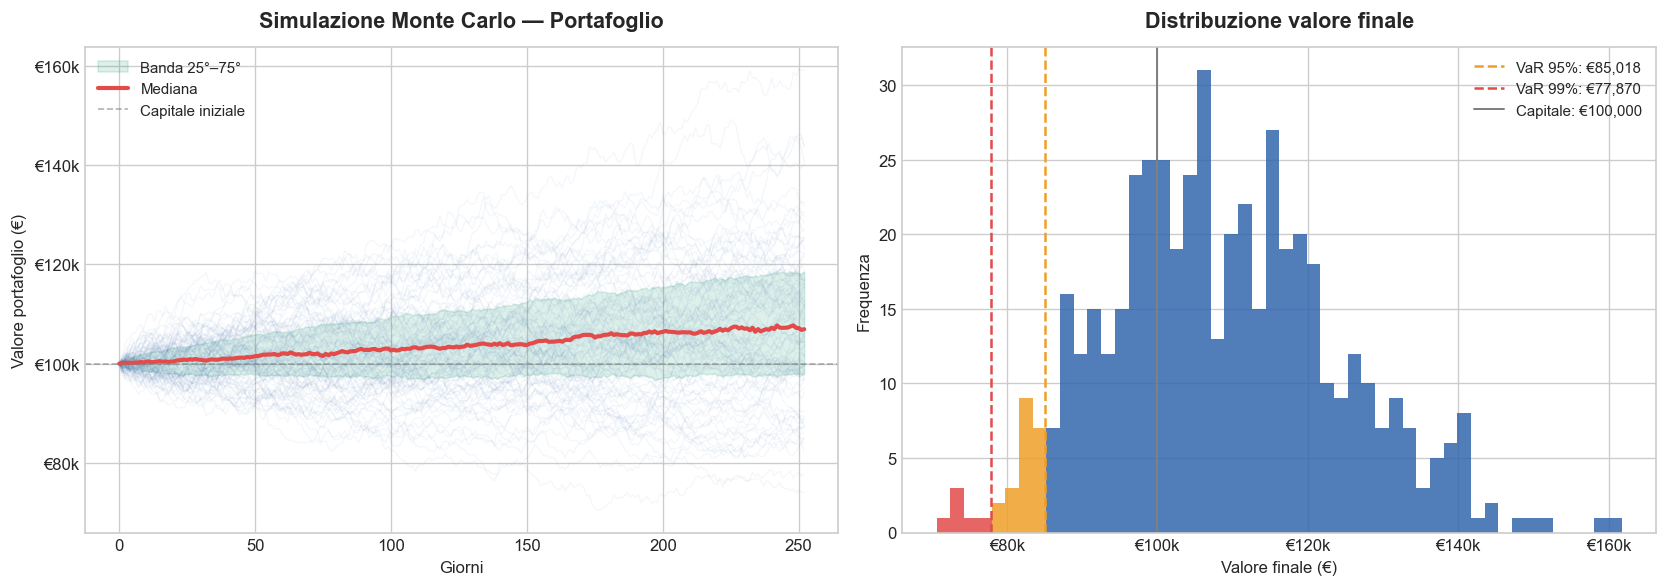

Grafico salvato come monte_carlo.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grafico percorsi ---
ax1 = axes[0]
days = np.arange(T_DAYS + 1)

for i in range(min(100, N_SIM)):
    ax1.plot(days, paths[i], color='#3266ad', alpha=0.05, linewidth=0.8)

p25  = np.percentile(paths, 25, axis=0)
p50  = np.percentile(paths, 50, axis=0)
p75  = np.percentile(paths, 75, axis=0)

ax1.fill_between(days, p25, p75, alpha=0.15, color='#1D9E75', label='Banda 25°–75°')
ax1.plot(days, p50, color='#E24B4A', linewidth=2.5, label='Mediana')
ax1.axhline(CAPITAL, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='Capitale iniziale')

ax1.set_title('Simulazione Monte Carlo — Portafoglio', fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Giorni')
ax1.set_ylabel('Valore portafoglio (€)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x/1000:.0f}k'))
ax1.legend(fontsize=9)

# --- Distribuzione valore finale ---
ax2 = axes[1]
var_95 = np.percentile(finals, 5)
var_99 = np.percentile(finals, 1)

n_bins = 50
counts, bin_edges, patches = ax2.hist(finals, bins=n_bins, edgecolor='none', alpha=0.85)

for patch, left in zip(patches, bin_edges[:-1]):
    if left < var_99:
        patch.set_facecolor('#E24B4A')
    elif left < var_95:
        patch.set_facecolor('#EF9F27')
    else:
        patch.set_facecolor('#3266ad')

ax2.axvline(var_95,  color='#EF9F27', linestyle='--', linewidth=1.5, label=f'VaR 95%: €{var_95:,.0f}')
ax2.axvline(var_99,  color='#E24B4A', linestyle='--', linewidth=1.5, label=f'VaR 99%: €{var_99:,.0f}')
ax2.axvline(CAPITAL, color='gray',    linestyle='-',  linewidth=1.2, label=f'Capitale: €{CAPITAL:,}')

ax2.set_title('Distribuzione valore finale', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Valore finale (€)')
ax2.set_ylabel('Frequenza')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x/1000:.0f}k'))
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('monte_carlo.png', bbox_inches='tight', dpi=150)
plt.show()
print("Grafico salvato come monte_carlo.png")

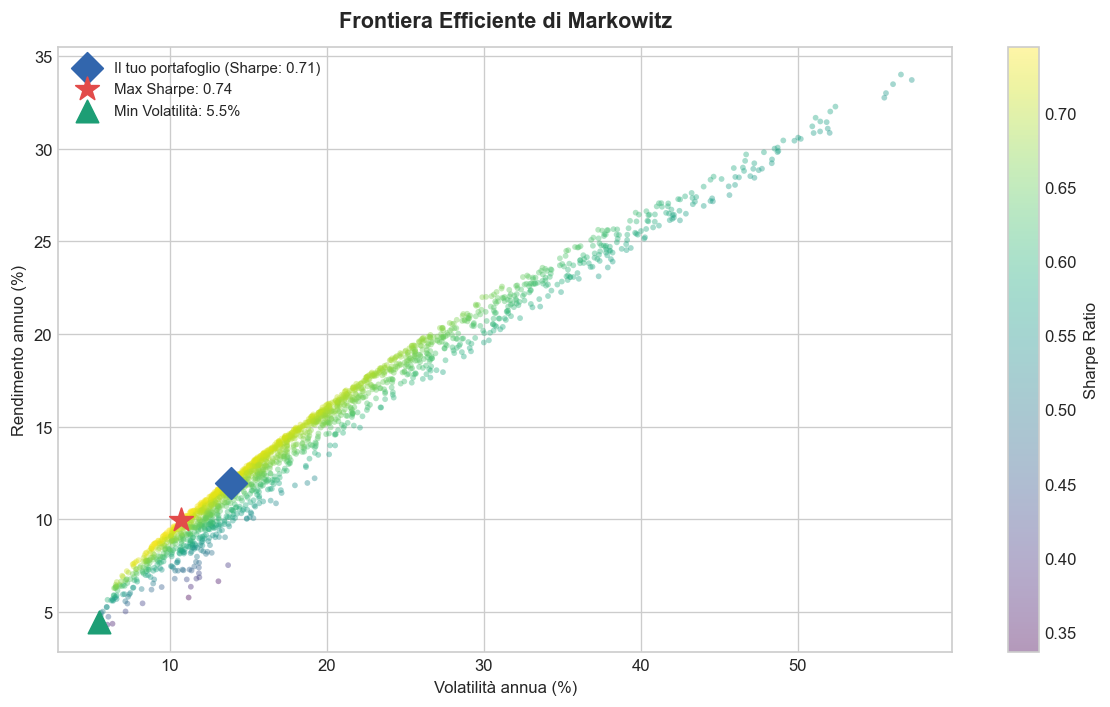


Portafoglio a Massimo Sharpe:
  S&P 500      15.8%
  Tech ETF     18.7%
  Bonds        39.9%
  Gold         16.1%
  Bitcoin      9.5%


In [7]:
N_PORTS = 2000

port_returns = []
port_vols    = []
port_sharpes = []
port_weights = []

for _ in range(N_PORTS):
    w = np.random.dirichlet(np.ones(len(weights)))   # pesi casuali che sommano a 1
    mu_i, sigma_i, sharpe_i = portfolio_stats(w, mus, sigmas, corr_matrix)
    port_returns.append(mu_i)
    port_vols.append(sigma_i)
    port_sharpes.append(sharpe_i)
    port_weights.append(w)

port_returns = np.array(port_returns)
port_vols    = np.array(port_vols)
port_sharpes = np.array(port_sharpes)

# Portafoglio ottimale (massimo Sharpe)
idx_max_sharpe = np.argmax(port_sharpes)
idx_min_vol    = np.argmin(port_vols)

fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(port_vols * 100, port_returns * 100,
                c=port_sharpes, cmap='viridis',
                alpha=0.4, s=12, linewidths=0)

plt.colorbar(sc, ax=ax, label='Sharpe Ratio')

# Portafoglio corrente
ax.scatter(sigma_p * 100, mu_p * 100,
           color='#3266ad', s=180, zorder=5,
           marker='D', label=f'Il tuo portafoglio (Sharpe: {sharpe_p:.2f})')

# Max Sharpe
ax.scatter(port_vols[idx_max_sharpe] * 100, port_returns[idx_max_sharpe] * 100,
           color='#E24B4A', s=220, zorder=5,
           marker='*', label=f'Max Sharpe: {port_sharpes[idx_max_sharpe]:.2f}')

# Min volatilità
ax.scatter(port_vols[idx_min_vol] * 100, port_returns[idx_min_vol] * 100,
           color='#1D9E75', s=180, zorder=5,
           marker='^', label=f'Min Volatilità: {port_vols[idx_min_vol]*100:.1f}%')

ax.set_title('Frontiera Efficiente di Markowitz', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Volatilità annua (%)')
ax.set_ylabel('Rendimento annuo (%)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('frontiera_efficiente.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\nPortafoglio a Massimo Sharpe:")
for name, w in zip(names, port_weights[idx_max_sharpe]):
    print(f"  {name:<12} {w*100:.1f}%")

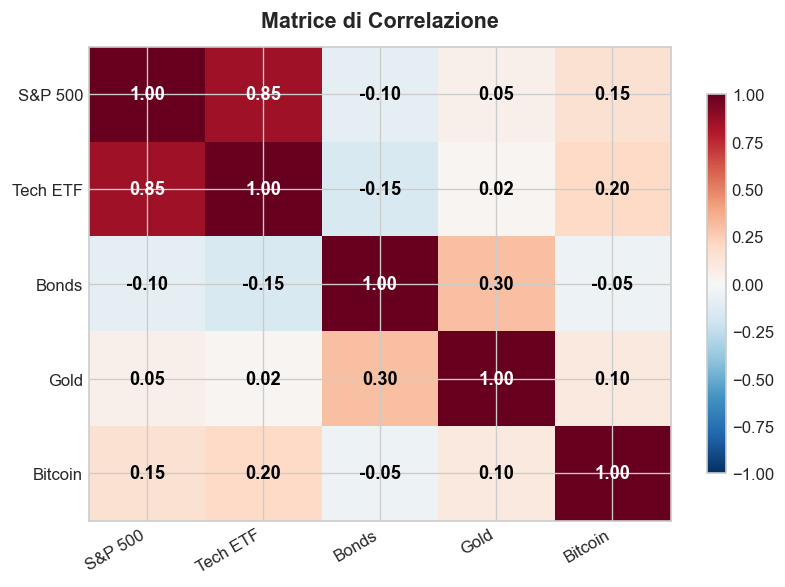

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)

ax.set_xticks(range(len(names)))
ax.set_yticks(range(len(names)))
ax.set_xticklabels(names, rotation=30, ha='right', fontsize=10)
ax.set_yticklabels(names, fontsize=10)

for i in range(len(names)):
    for j in range(len(names)):
        val = corr_matrix[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=11, fontweight='bold', color=color)

ax.set_title('Matrice di Correlazione', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('correlazione.png', bbox_inches='tight', dpi=150)
plt.show()

# Portfolio Monte Carlo Simulation

Monte Carlo simulation on a multi-asset portfolio built with Python.

## Overview
- 5-asset portfolio: S&P 500, Tech ETF, Bonds, Gold, Bitcoin
- Correlated asset returns via Cholesky decomposition
- Markowitz efficient frontier with 2,000 random portfolios
- Risk metrics: VaR 95/99%, Sharpe Ratio, annual volatility

## Libraries
numpy · pandas · matplotlib · scipy

## How to run
1. `pip3 install numpy pandas matplotlib scipy`
2. `jupyter notebook`
3. Open `portfolio_montecarlo.ipynb` and run all cells